# Training report — `cap4500_yolov8s`

Baseline run of the Second Vision obstacle detector: **YOLOv8s, 15 classes, 640px**,
trained on the cap-4500 condition and evaluated on the frozen test split.

Everything below is read from artefacts on disk — `results.csv`, `args.yaml`,
`provenance.json`, and the evaluation outputs — so the report cannot drift from the
run it describes. Re-running the notebook after another arm regenerates it.

Related decisions: **DEC-119** (bundle and frozen eval sets) · **DEC-120** (run
configuration) · **DEC-121** (ablation optionality) · **DEC-122** (pre-registered
criterion) · **DEC-123** (in-place JPEG repair).

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd()
while not (ROOT / "config" / "classes.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RUN  = ROOT / "runs" / "detect" / "cap4500_yolov8s"
FIGS = ROOT / "docs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

df      = pd.read_csv(RUN / "eval_fp32_test_per_class.csv")
summary = json.loads((RUN / "eval_fp32_test_summary.json").read_text())
prov    = json.loads((RUN / "provenance.json").read_text())
hist    = pd.read_csv(RUN / "results.csv")
hist.columns = [c.strip() for c in hist.columns]

TARGET = summary["target_map50"]
print(f"artefacts: {RUN.relative_to(ROOT)}")
print(f"figures  : {FIGS.relative_to(ROOT)}")

artefacts: runs/detect/cap4500_yolov8s
figures  : docs/figures


## 1. Provenance

The reproducibility record. `pip_freeze.txt` in the run directory — not
`requirements-train.txt` — is the authoritative environment (DEC-120), because it
captures the pod template's CUDA-matched torch alongside everything pip resolved.

In [2]:
import yaml
args = yaml.safe_load((RUN / "args.yaml").read_text())

rows = [
    ("run name",        prov["data_yaml_contents"].get("nc") and RUN.name),
    ("finished",        prov["finished"]),
    ("git SHA",         prov["git_sha"][:12]),
    ("data.yaml",       prov["data_yaml"]),
    ("classes (nc)",    prov["data_yaml_contents"]["nc"]),
    ("loggers armed",   ", ".join(k for k, v in prov["loggers"].items() if v) or "none"),
    ("smoke run?",      prov["smoke"]),
]
for k, v in rows:
    print(f"  {k:<16} {v}")

freeze = (RUN / "pip_freeze.txt").read_text().splitlines()
key = [l for l in freeze if l.lower().startswith(("torch==", "ultralytics==", "numpy==", "opencv"))]
print("\n  key packages:")
for l in key:
    print(f"    {l}")

  run name         cap4500_yolov8s
  finished         2026-09-06 23:58:59
  git SHA          9364082103d4
  data.yaml        /workspace/final_cap4500/data.yaml
  classes (nc)     15
  loggers armed    tensorboard, comet
  smoke run?       False

  key packages:
    numpy==2.1.2
    opencv-python==5.0.0.93
    torch==2.8.0+cu128
    ultralytics==8.4.118


## 2. Configuration

`config/training.yaml` deliberately sets **no augmentation keys**, so ultralytics'
own defaults apply — the correct behaviour for a baseline (DEC-120).

Note `augment: False` below is the **test-time augmentation** flag for
validation/prediction. It has nothing to do with training augmentation, which is
governed by the individual keys in the second table.

In [3]:
sched = ["model", "imgsz", "epochs", "batch", "patience", "optimizer", "lr0", "lrf",
         "momentum", "weight_decay", "warmup_epochs", "seed", "amp", "fraction",
         "close_mosaic", "workers", "cache", "rect"]
aug   = ["hsv_h", "hsv_s", "hsv_v", "degrees", "translate", "scale", "shear",
         "perspective", "flipud", "fliplr", "bgr", "mosaic", "mixup", "cutmix",
         "copy_paste", "erasing", "auto_augment", "augment"]

print("SCHEDULE")
for k in sched:
    print(f"  {k:<15} {args.get(k)}")
print("\nAUGMENTATION (ultralytics defaults — none overridden)")
for k in aug:
    print(f"  {k:<15} {args.get(k)}")

print("\nNotes:")
print(f"  patience={args.get('patience')} -> early stopping effectively disabled, so every")
print("  ablation arm runs an identical 100-epoch schedule (DEC-120). best.pt is still")
print("  chosen by fitness, so this costs GPU time, not model quality.")
print(f"  optimizer resolved to {args.get('optimizer')}; 'auto' picks MuSGD above 10,000")
print("  iterations, and all three cap arms clear that threshold (DEC-123).")

SCHEDULE
  model           yolov8s.pt
  imgsz           640
  epochs          100
  batch           32
  patience        100000
  optimizer       auto
  lr0             0.01
  lrf             0.01
  momentum        0.937
  weight_decay    0.0005
  warmup_epochs   3.0
  seed            42
  amp             True
  fraction        1.0
  close_mosaic    10
  workers         8
  cache           False
  rect            False

AUGMENTATION (ultralytics defaults — none overridden)
  hsv_h           0.015
  hsv_s           0.7
  hsv_v           0.4
  degrees         0.0
  translate       0.1
  scale           0.5
  shear           0.0
  perspective     0.0
  flipud          0.0
  fliplr          0.5
  bgr             0.0
  mosaic          1.0
  mixup           0.0
  cutmix          0.0
  copy_paste      0.0
  erasing         0.4
  auto_augment    randaugment
  augment         False

Notes:
  patience=100000 -> early stopping effectively disabled, so every
  ablation arm runs an identical 100-ep

## 3. Dataset

The cap-4500 condition. **val and test are frozen** and byte-identical across every
cap condition (DEC-119) — only the training set varies — so any later arm is directly
comparable to this one.

In [4]:
meta_path = ROOT / "dataset" / "bundle" / "bundle_meta.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    print(f"  bundle built  : {meta['created']}  (git {meta.get('git_sha','?')[:12]})")
    print(f"  superset      : cap{meta['superset_cap']}, {meta['superset_images']:,} images")
    print(f"  resize        : {meta['resize']}")
    print()
    print("  condition   train     val    test   (val/test identical across arms)")
    for cap, c in meta["conditions"].items():
        mark = "  <- this run" if cap == "4500" else ""
        print(f"    cap{cap:<6} {c['train']:>6,}  {c['val']:>6,}  {c['test']:>6,}{mark}")
else:
    print("  bundle_meta.json not present locally (pod-side only)")

print(f"\n  test split evaluated: {df['instances'].sum():,} instances "
      f"across {summary['ground_truth_instances']:,} ground-truth objects")
print(f"  background images   : 0 by design (DEC-120)")

  bundle built  : 2026-09-06 23:16:56  (git 63e9a2677062)
  superset      : cap9000, 54,514 images
  resize        : downscale-only, long side to imgsz, BILINEAR, JPEG q95; PNG kept as PNG

  condition   train     val    test   (val/test identical across arms)
    cap1500   14,202   6,644   6,403
    cap4500   30,123   6,644   6,403  <- this run
    cap9000   41,467   6,644   6,403

  test split evaluated: 20,310 instances across 20,310 ground-truth objects
  background images   : 0 by design (DEC-120)


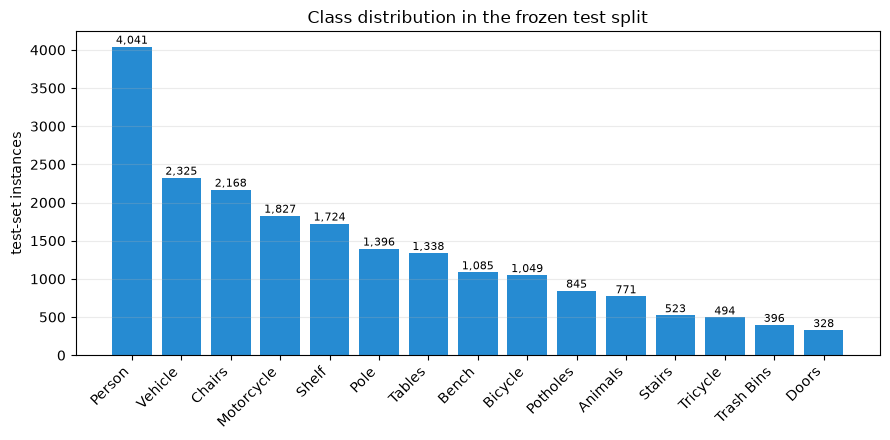

  imbalance ratio (max/min instances): 12.32x  (Person 4,041 vs Doors 328)


In [5]:
d = df.sort_values("instances", ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(d["class"], d["instances"], color="#268bd2")
ax.set_ylabel("test-set instances")
ax.set_title("Class distribution in the frozen test split")
ax.set_xticks(range(len(d)))
ax.set_xticklabels(d["class"], rotation=45, ha="right")
for i, v in enumerate(d["instances"]):
    ax.text(i, v + 40, f"{int(v):,}", ha="center", fontsize=8)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGS / "test_class_distribution.png", dpi=200)
plt.show()

print(f"  imbalance ratio (max/min instances): "
      f"{d['instances'].max()/d['instances'].min():.2f}x  "
      f"({d.iloc[0]['class']} {d['instances'].max():,} vs "
      f"{d.iloc[-1]['class']} {d['instances'].min():,})")

## 4. Training progress

`best.pt` is selected by **fitness** = `0.1·mAP50 + 0.9·mAP50-95`, not by the final
epoch. That is what makes running past the peak safe.

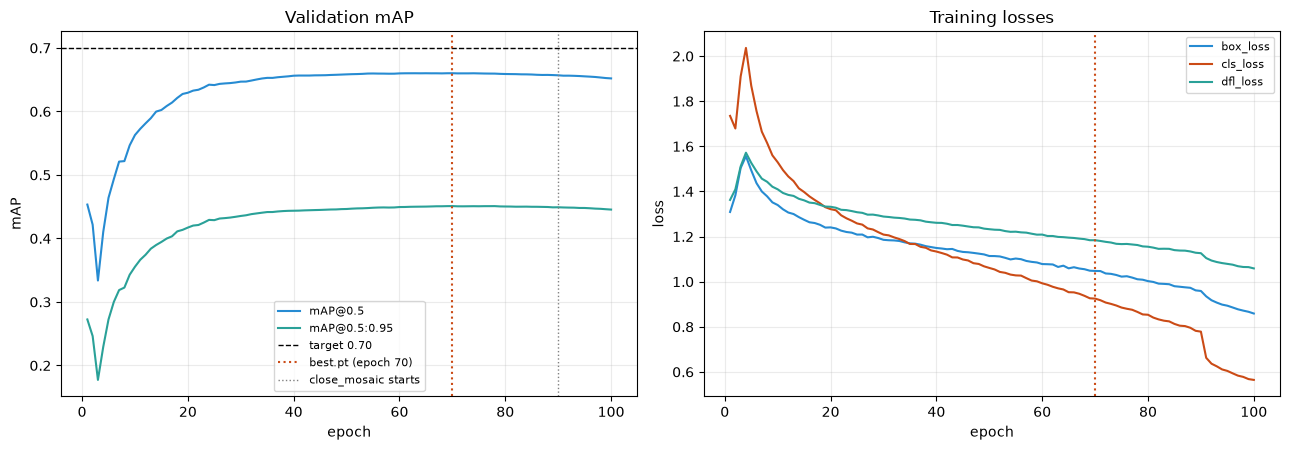

In [6]:
fit = 0.1 * hist["metrics/mAP50(B)"] + 0.9 * hist["metrics/mAP50-95(B)"]
best_ep = int(hist.loc[fit.idxmax(), "epoch"])
last_ep = int(hist["epoch"].iloc[-1])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(hist["epoch"], hist["metrics/mAP50(B)"], label="mAP@0.5", color="#268bd2")
a1.plot(hist["epoch"], hist["metrics/mAP50-95(B)"], label="mAP@0.5:0.95", color="#2aa198")
a1.axhline(TARGET, color="k", ls="--", lw=1, label=f"target {TARGET:.2f}")
a1.axvline(best_ep, color="#cb4b16", ls=":", lw=1.5, label=f"best.pt (epoch {best_ep})")
if args.get("close_mosaic"):
    a1.axvline(last_ep - args["close_mosaic"], color="grey", ls=":", lw=1,
               label="close_mosaic starts")
a1.set_xlabel("epoch"); a1.set_ylabel("mAP"); a1.set_title("Validation mAP")
a1.legend(fontsize=8); a1.grid(alpha=0.25)

for c, col in [("train/box_loss", "#268bd2"), ("train/cls_loss", "#cb4b16"),
               ("train/dfl_loss", "#2aa198")]:
    a2.plot(hist["epoch"], hist[c], label=c.split("/")[1], color=col)
a2.axvline(best_ep, color="#cb4b16", ls=":", lw=1.5)
a2.set_xlabel("epoch"); a2.set_ylabel("loss"); a2.set_title("Training losses")
a2.legend(fontsize=8); a2.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGS / "training_curves.png", dpi=200)
plt.show()

In [7]:
m = hist["metrics/mAP50(B)"]
print("  mean mAP@0.5 by 10-epoch block")
for a in range(0, len(m), 10):
    blk = m[a:a+10]
    bar = "#" * int(blk.mean() * 60)
    print(f"    {a+1:>3}-{min(a+10, len(m)):<3}  {blk.mean():.4f}  {bar}")

print()
print(f"  peak (best.pt)  epoch {best_ep:>3}: mAP50 {hist.loc[fit.idxmax(),'metrics/mAP50(B)']:.4f}"
      f"   mAP50-95 {hist.loc[fit.idxmax(),'metrics/mAP50-95(B)']:.4f}")
print(f"  final           epoch {last_ep:>3}: mAP50 {m.iloc[-1]:.4f}   "
      f"mAP50-95 {hist['metrics/mAP50-95(B)'].iloc[-1]:.4f}")
print(f"  drift after peak        : {m.iloc[-1] - m.max():+.4f} mAP50")

secs = hist["time"].iloc[-1]
print(f"\n  wall clock  : {secs/3600:.2f} h over {last_ep} epochs "
      f"({secs/last_ep:.0f} s/epoch)")

d_box = hist['train/box_loss'].iloc[-1] - hist['train/box_loss'].iloc[0]
d_cls = hist['train/cls_loss'].iloc[-1] - hist['train/cls_loss'].iloc[0]
print(f"\n  Training losses fell throughout (box {d_box:+.3f}, cls {d_cls:+.3f}) while")
print(f"  validation mAP declined after epoch {best_ep}. That divergence is mild")
print("  overfitting; fitness-based checkpoint selection absorbs it entirely.")

  mean mAP@0.5 by 10-epoch block
      1-10   0.4729  ############################
     11-20   0.6046  ####################################
     21-30   0.6413  ######################################
     31-40   0.6524  #######################################
     41-50   0.6572  #######################################
     51-60   0.6594  #######################################
     61-70   0.6601  #######################################
     71-80   0.6597  #######################################
     81-90   0.6579  #######################################
     91-100  0.6547  #######################################

  peak (best.pt)  epoch  70: mAP50 0.6602   mAP50-95 0.4510
  final           epoch 100: mAP50 0.6520   mAP50-95 0.4455
  drift after peak        : -0.0081 mAP50

  wall clock  : 2.98 h over 100 epochs (107 s/epoch)

  Training losses fell throughout (box -0.450, cls -1.170) while
  validation mAP declined after epoch 70. That divergence is mild
  overfitting; fitness-

## 5. Results — overall and per class

The headline number is a mean, so it conceals its own distribution. This is where it
actually comes from.

In [8]:
print(f"  mAP@0.5       {summary['map50']:.4f}     target {TARGET:.2f}"
      f"   {'PASS' if summary['primary_pass'] else 'FAIL'}")
print(f"  mAP@0.5:0.95  {summary['map50_95']:.4f}")
print(f"  verdict       {summary['verdict']}  (reported only — DEC-122 gates nothing)")
print()
print("  per-class floors")
for f in summary["per_class_floors"]:
    got = f"{f['map50']:.4f}" if f["map50"] is not None else "ABSENT"
    print(f"    {f['class']:<12} {got}  >= {f['floor']:.2f}   {'PASS' if f['pass'] else 'FAIL'}")
print(f"\n  expected-weak, pre-registered with no floor: "
      f"{', '.join(summary['expected_weak'])}")
for c in summary["expected_weak"]:
    v = df.loc[df["class"] == c, "mAP50"].iloc[0]
    print(f"    {c:<12} {v:.4f}")

  mAP@0.5       0.6695     target 0.70   FAIL
  mAP@0.5:0.95  0.4530
  verdict       FAIL  (reported only — DEC-122 gates nothing)

  per-class floors
    Person       0.7177  >= 0.75   FAIL
    Vehicle      0.8026  >= 0.75   PASS
    Motorcycle   0.8140  >= 0.65   PASS
    Tricycle     0.8421  >= 0.65   PASS
    Bicycle      0.7265  >= 0.65   PASS

  expected-weak, pre-registered with no floor: Pole, Potholes
    Pole         0.3795
    Potholes     0.6849


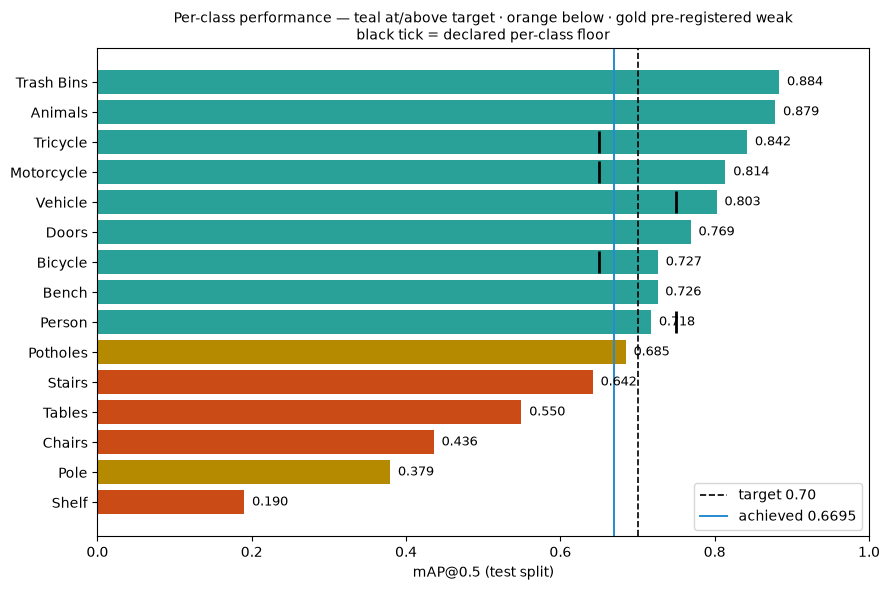

  all 15 classes                    : 0.6695
  excluding Shelf, Pole, Chairs     : 0.7531  (12 classes)

  Effect of excluding each weak class from the mean (DIAGNOSTIC ONLY):
    without Shelf        -> 0.7037  (clears 0.70)
    without Pole         -> 0.6902  (still below 0.70)
    without Chairs       -> 0.6862  (still below 0.70)


In [9]:
d = df.sort_values("mAP50")
colors = ["#b58900" if w else ("#2aa198" if v >= TARGET else "#cb4b16")
          for w, v in zip(d["expected_weak"], d["mAP50"])]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(d["class"], d["mAP50"], color=colors)
ax.axvline(TARGET, color="k", ls="--", lw=1.2, label=f"target {TARGET:.2f}")
ax.axvline(summary["map50"], color="#268bd2", lw=1.4,
           label=f"achieved {summary['map50']:.4f}")
for i, (_, r) in enumerate(d.iterrows()):
    ax.text(r["mAP50"] + 0.01, i, f"{r['mAP50']:.3f}", va="center", fontsize=9)
    if pd.notna(r["floor"]):
        ax.plot([r["floor"]], [i], marker="|", ms=16, mew=2, color="k")
ax.set_xlim(0, 1.0); ax.set_xlabel("mAP@0.5 (test split)")
ax.set_title("Per-class performance — teal at/above target · orange below · "
             "gold pre-registered weak\nblack tick = declared per-class floor", fontsize=10)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGS / "per_class_map50.png", dpi=200)
plt.show()

weak = df.nsmallest(3, "mAP50")["class"].tolist()
rest = df[~df["class"].isin(weak)]
print(f"  all 15 classes                    : {df['mAP50'].mean():.4f}")
print(f"  excluding {', '.join(weak):<24}: {rest['mAP50'].mean():.4f}  ({len(rest)} classes)")
print()
print("  Effect of excluding each weak class from the mean (DIAGNOSTIC ONLY):")
for c in weak:
    sub = df[df["class"] != c]["mAP50"].mean()
    print(f"    without {c:<12} -> {sub:.4f}"
          f"  ({'clears' if sub >= TARGET else 'still below'} {TARGET:.2f})")

> **Those exclusion figures are diagnostics, not results.** Dropping a class because
> it is inconvenient is metric-gaming and would not survive a defence. Dropping one
> because its annotations are demonstrably inconsistent is a documented data decision
> with precedent (DEC-100). The arithmetic says which classes *would* move the mean;
> only inspecting the annotations can say whether doing so is defensible.

## 6. Does class frequency predict performance?

The question the cap ablation was designed around. If frequency drove accuracy, the
points would trend upward from left to right.

In [ ]:
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df["instances"], df["mAP50"], s=70, zorder=3,
           c=["#b58900" if w else "#268bd2" for w in df["expected_weak"]])
for _, r in df.iterrows():
    ax.annotate(r["class"], (r["instances"], r["mAP50"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)
ax.axhline(TARGET, color="k", ls="--", lw=1, label=f"target {TARGET:.2f}")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_xlabel("test-set instances (log scale)"); ax.set_ylabel("mAP@0.5")
ax.set_title("Per-class mAP vs class frequency")
ax.legend(loc="lower right"); ax.grid(alpha=0.25, zorder=0)
fig.tight_layout()
fig.savefig(FIGS / "map_vs_frequency.png", dpi=200)
plt.show()

rho, p = spearmanr(df["instances"], df["mAP50"])
print(f"  Spearman rho = {rho:+.3f}   p = {p:.3f}")
hi = df.loc[df["instances"].idxmax()]
lo = df.loc[df["instances"].idxmin()]
print(f"  most frequent : {hi['class']:<12} {int(hi['instances']):>6,} inst -> mAP50 {hi['mAP50']:.3f}")
print(f"  least frequent: {lo['class']:<12} {int(lo['instances']):>6,} inst -> mAP50 {lo['mAP50']:.3f}")
print()
print("  Interpretation belongs in the write-up, but note that if the least frequent")
print("  class outperforms the most frequent one, per-class difficulty and annotation")
print("  quality dominate raw frequency at this dataset scale — which is precisely the")
print("  hypothesis the 1500/4500/9000 ablation exists to test (DEC-121).")

## 7. Why the weak classes are weak

A class can score badly by inventing detections (low precision) or by missing real
objects (low recall). These call for different fixes, and the distinction matters more
than the mAP value itself.

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(df["recall"], df["precision"], s=70, zorder=3,
           c=["#b58900" if w else "#268bd2" for w in df["expected_weak"]])
for _, r in df.iterrows():
    ax.annotate(r["class"], (r["recall"], r["precision"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)
ax.axhline(0.5, color="grey", lw=0.8, ls=":"); ax.axvline(0.5, color="grey", lw=0.8, ls=":")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision vs recall per class\n"
             "lower-right = misses real objects · upper-left = over-predicts")
ax.grid(alpha=0.25, zorder=0)
fig.tight_layout()
fig.savefig(FIGS / "precision_recall_per_class.png", dpi=200)
plt.show()

g = df.assign(gap=df["precision"] - df["recall"]).nlargest(4, "gap")
print("  Most recall-limited (precision >> recall):")
for _, r in g.iterrows():
    print(f"    {r['class']:<12} P {r['precision']:.3f}  R {r['recall']:.3f}  "
          f"gap {r['gap']:+.3f}   missed {int(r['missed_detections']):,} of {int(r['instances']):,}"
          f"  ({int(r['instances'])/int(r['images']):.1f} inst/image)")
print()
print("  A class with very low recall AND high instance density is more often an")
print("  annotation-consistency problem than a capacity one: the same object")
print("  photographed as a unit and as its parts gives contradictory targets.")

## 8. Error budget

`false_positives_vs_background` is the background column of the confusion matrix at
**conf 0.25** — not the 0.001 used for mAP. The dataset contains **zero background
images** by design (DEC-120), so this is the agreed substitute measure and belongs in
the limitations section. 0.25 is also the threshold baked into `hef_deploy`, so this
figure reflects what actually ships.

In [ ]:
d = df.sort_values("instances", ascending=False)
x = range(len(d))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], d["false_positives_vs_background"], width=0.4,
       color="#cb4b16", label="false positives vs background")
ax.bar([i + 0.2 for i in x], d["missed_detections"], width=0.4,
       color="#268bd2", label="missed detections")
ax.plot(list(x), d["instances"], color="k", lw=1, ls="--", marker=".",
        label="ground-truth instances")
ax.set_xticks(list(x)); ax.set_xticklabels(d["class"], rotation=45, ha="right")
ax.set_ylabel("count")
ax.set_title(f"Error budget per class (conf {summary['confusion_matrix_conf']})")
ax.legend(); ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGS / "error_budget.png", dpi=200)
plt.show()

fp, inst = int(df["false_positives_vs_background"].sum()), int(df["instances"].sum())
print(f"  false positives : {fp:,}")
print(f"  gt instances    : {inst:,}")
print(f"  rate            : {fp/inst:.3f} per instance")

## 9. Summary table

Written to `docs/figures/per_class_table.csv` and printed as markdown for pasting
straight into the write-up.

In [ ]:
out = (df[["class", "instances", "images", "precision", "recall", "f1",
           "mAP50", "mAP50_95", "false_positives_vs_background",
           "missed_detections", "expected_weak"]]
       .sort_values("mAP50", ascending=False)
       .round(4))
out.to_csv(FIGS / "per_class_table.csv", index=False)
print(out.to_markdown(index=False))

print(f"\n  OVERALL  mAP@0.5 {summary['map50']:.4f} | mAP@0.5:0.95 "
      f"{summary['map50_95']:.4f} | target {TARGET:.2f} | {summary['verdict']}")
print(f"\n  experiments.md row:")
print(f"  | {summary['run']} | {summary['tag']} | {summary['split']} | "
      f"{summary['map50']:.4f} | {summary['map50_95']:.4f} | {fp} | {summary['verdict']} |")
print(f"\n  figures written to {FIGS}")
for f in sorted(FIGS.glob('*.png')):
    print(f"    {f.name}")